In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


DATASET_PATH = r"D:\Advisory model\mango_advisory_training_dataset_v2.csv"

OUTPUT_DIR = "eda_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:

print("\n" + "=" * 70)
print("MANGO AI ADVISORY MODEL - EDA")
print("=" * 70)

if not os.path.exists(DATASET_PATH):

    raise FileNotFoundError(
        f"\nDataset not found:\n{DATASET_PATH}\n\n"
        "Please change DATASET_PATH at the top of this file."
    )

df = pd.read_csv(DATASET_PATH)

print("\nDataset loaded successfully.")

print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")


MANGO AI ADVISORY MODEL - EDA

Dataset loaded successfully.
Number of rows    : 486000
Number of columns : 30


In [ ]:
print("\n\n" + "=" * 70)
print("EDA 1 - DATASET OVERVIEW")
print("=" * 70)

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")

for number, column in enumerate(df.columns, start=1):
    print(f"{number:2}. {column}")


print("\nData types:")
print(df.dtypes)


print("\nData type summary:")
print(df.dtypes.value_counts())


print("\nFirst five records:")
print(df.head())


# Save overview
overview = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "missing_values": df.isnull().sum().values,
    "unique_values": [
        df[column].nunique(dropna=True)
        for column in df.columns
    ]
})

overview.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "01_dataset_overview.csv"
    ),
    index=False
)



EDA 1 - DATASET OVERVIEW

Dataset shape:
(486000, 30)

Column names:
 1. _soil_profile_id
 2. city
 3. country
 4. latitude
 5. longitude
 6. elevation
 7. year
 8. month
 9. N
10. P
11. K
12. ph
13. annual_temperature_c
14. annual_rainfall_mm
15. annual_et0_mm
16. monthly_temperature_c
17. monthly_rainfall_mm
18. monthly_precipitation_mm
19. monthly_et0_mm
20. monthly_wind_max_kmh
21. monthly_radiation
22. precipitation_hours
23. water_balance_mm
24. suitability
25. planting_period
26. irrigation_need
27. drought_risk
28. nutrient_condition
29. label_source
30. data_type

Data types:
_soil_profile_id              int64
city                            str
country                         str
latitude                    float64
longitude                   float64
elevation                   float64
year                          int64
month                         int64
N                             int64
P                             int64
K                             int64
ph        

In [ ]:

print("\n\n" + "=" * 70)
print("EDA 2 - DATA QUALITY ANALYSIS")
print("=" * 70)


missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)


missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})


print("\nMissing values:")
print(missing_table)


duplicate_count = df.duplicated().sum()

print("\nTotal missing values:",
      df.isnull().sum().sum())

print("Total duplicate rows:",
      duplicate_count)



missing_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "02_missing_values.csv"
    )
)


quality_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Total Missing Values",
        "Duplicate Rows"
    ],

    "Value": [
        len(df),
        len(df.columns),
        int(df.isnull().sum().sum()),
        int(duplicate_count)
    ]
})


quality_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "02_data_quality_summary.csv"
    ),
    index=False
)




EDA 2 - DATA QUALITY ANALYSIS

Missing values:
                          Missing Count  Missing Percentage
_soil_profile_id                      0                 0.0
city                                  0                 0.0
country                               0                 0.0
latitude                              0                 0.0
longitude                             0                 0.0
elevation                             0                 0.0
year                                  0                 0.0
month                                 0                 0.0
N                                     0                 0.0
P                                     0                 0.0
K                                     0                 0.0
ph                                    0                 0.0
annual_temperature_c                  0                 0.0
annual_rainfall_mm                    0                 0.0
annual_et0_mm                         0            

In [ ]:
print("\n\n" + "=" * 70)
print("EDA 3 - DESCRIPTIVE STATISTICS")
print("=" * 70)


important_features = [

    
    "N",
    "P",
    "K",
    "ph",

    "annual_temperature_c",
    "annual_rainfall_mm",
    "annual_et0_mm",

    "monthly_temperature_c",
    "monthly_rainfall_mm",
    "monthly_et0_mm",

  
    "monthly_wind_max_kmh",
    "monthly_radiation",
    "precipitation_hours",
    "water_balance_mm",
    "elevation"
]


available_features = [

    feature
    for feature in important_features
    if feature in df.columns

]


print("\nFeatures included in descriptive statistics:")

print(available_features)


if len(available_features) > 0:

    descriptive_statistics = (
        df[available_features]
        .describe()
        .T
        .round(2)
    )

    print("\nDescriptive statistics:")
    print(descriptive_statistics)


    descriptive_statistics.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "03_descriptive_statistics.csv"
        )
    )

else:

    print(
        "\nNo expected numerical features "
        "were found."
    )




EDA 3 - DESCRIPTIVE STATISTICS

Features included in descriptive statistics:
['N', 'P', 'K', 'ph', 'annual_temperature_c', 'annual_rainfall_mm', 'annual_et0_mm', 'monthly_temperature_c', 'monthly_rainfall_mm', 'monthly_et0_mm', 'monthly_wind_max_kmh', 'monthly_radiation', 'precipitation_hours', 'water_balance_mm', 'elevation']

Descriptive statistics:
                          count     mean     std     min      25%      50%  \
N                      486000.0    20.07   12.27    0.00     9.00    21.00   
P                      486000.0    27.18    7.63   15.00    19.75    27.50   
K                      486000.0    29.92    3.08   25.00    27.00    30.00   
ph                     486000.0     5.77    0.70    4.51     5.18     5.74   
annual_temperature_c   486000.0    26.23    1.50   20.06    26.17    26.57   
annual_rainfall_mm     486000.0  2147.08  632.62  387.10  1709.20  2288.90   
annual_et0_mm          486000.0  1393.18  198.46  599.24  1320.17  1366.22   
monthly_temperature_



EDA 4 - TARGET VARIABLE DISTRIBUTION

Available target variables:
['suitability', 'irrigation_need', 'drought_risk', 'nutrient_condition']

------------------------------------------------------------
TARGET: SUITABILITY
------------------------------------------------------------
                      Count  Percentage
suitability                            
Not Suitable         249120       51.26
Moderately Suitable  161280       33.19
Suitable              75600       15.56

------------------------------------------------------------
TARGET: IRRIGATION_NEED
------------------------------------------------------------
                  Count  Percentage
irrigation_need                    
Low              295300       60.76
High             121200       24.94
Moderate          69500       14.30

------------------------------------------------------------
TARGET: DROUGHT_RISK
------------------------------------------------------------
               Count  Percentage
drought_risk

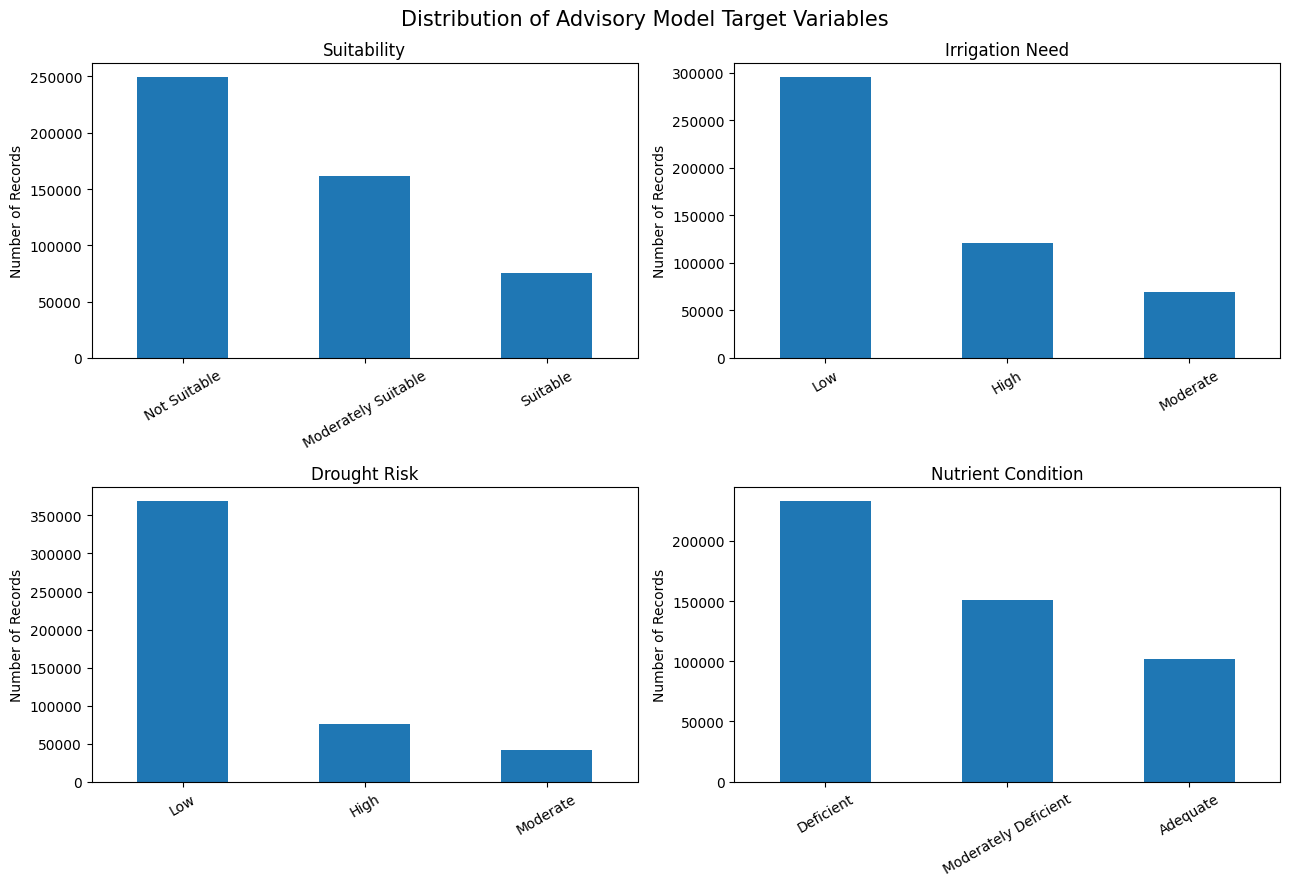

In [ ]:

print("\n\n" + "=" * 70)
print("EDA 4 - TARGET VARIABLE DISTRIBUTION")
print("=" * 70)


targets = [

    "suitability",
    "irrigation_need",
    "drought_risk",
    "nutrient_condition"

]


available_targets = [

    target
    for target in targets
    if target in df.columns

]


print("\nAvailable target variables:")
print(available_targets)



for target in available_targets:

    print("\n" + "-" * 60)

    print(
        f"TARGET: {target.upper()}"
    )

    print("-" * 60)


    counts = (
        df[target]
        .value_counts(dropna=False)
    )


    percentages = (
        df[target]
        .value_counts(
            normalize=True,
            dropna=False
        )
        * 100
    ).round(2)


    distribution = pd.DataFrame({

        "Count": counts,

        "Percentage": percentages

    })


    print(distribution)


    distribution.to_csv(

        os.path.join(
            OUTPUT_DIR,
            f"04_{target}_distribution.csv"
        )

    )




if len(available_targets) > 0:

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13, 9)
    )


    axes = axes.flatten()


    for ax, target in zip(
        axes,
        available_targets
    ):

        counts = (
            df[target]
            .value_counts()
        )


        counts.plot(
            kind="bar",
            ax=ax
        )


        ax.set_title(
            target
            .replace("_", " ")
            .title()
        )


        ax.set_xlabel("")

        ax.set_ylabel(
            "Number of Records"
        )


        ax.tick_params(
            axis="x",
            rotation=30
        )



    for ax in axes[len(available_targets):]:

        ax.axis("off")


    fig.suptitle(
        "Distribution of Advisory Model Target Variables",
        fontsize=15
    )


    plt.tight_layout()


    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "04_target_distributions.png"
        ),

        dpi=300,
        bbox_inches="tight"

    )


    plt.show()



EDA 5 - SOIL PARAMETER DISTRIBUTIONS

Soil features:
['N', 'P', 'K', 'ph']

--------------------------------------------------
SOIL FEATURE: N
--------------------------------------------------
count    486000.00
mean         20.07
std          12.27
min           0.00
25%           9.00
50%          21.00
75%          30.25
max          40.00
Name: N, dtype: float64

--------------------------------------------------
SOIL FEATURE: P
--------------------------------------------------
count    486000.00
mean         27.18
std           7.63
min          15.00
25%          19.75
50%          27.50
75%          35.00
max          40.00
Name: P, dtype: float64

--------------------------------------------------
SOIL FEATURE: K
--------------------------------------------------
count    486000.00
mean         29.92
std           3.08
min          25.00
25%          27.00
50%          30.00
75%          32.00
max          35.00
Name: K, dtype: float64

-------------------------------------

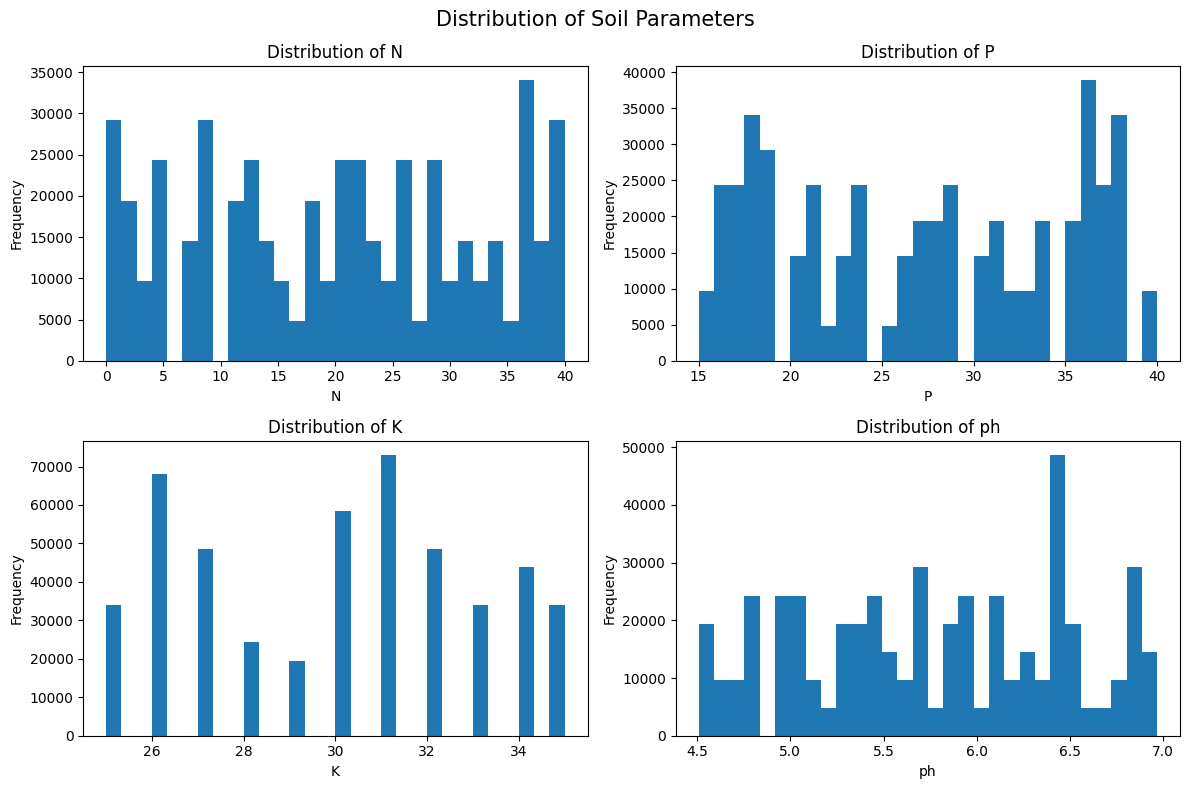

In [ ]:

print("\n\n" + "=" * 70)
print("EDA 5 - SOIL PARAMETER DISTRIBUTIONS")
print("=" * 70)


soil_features = [

    "N",
    "P",
    "K",
    "ph"

]


available_soil_features = [

    feature
    for feature in soil_features
    if feature in df.columns

]


print("\nSoil features:")
print(available_soil_features)


for feature in available_soil_features:

    print("\n" + "-" * 50)

    print(
        f"SOIL FEATURE: {feature}"
    )

    print("-" * 50)

    print(
        df[feature]
        .describe()
        .round(2)
    )


if len(available_soil_features) > 0:

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 8)
    )


    axes = axes.flatten()


    for ax, feature in zip(
        axes,
        available_soil_features
    ):

        ax.hist(
            df[feature].dropna(),
            bins=30
        )


        ax.set_title(
            f"Distribution of {feature}"
        )


        ax.set_xlabel(feature)

        ax.set_ylabel(
            "Frequency"
        )


    for ax in axes[len(available_soil_features):]:

        ax.axis("off")


    fig.suptitle(
        "Distribution of Soil Parameters",
        fontsize=15
    )


    plt.tight_layout()


    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "05_soil_distributions.png"
        ),

        dpi=300,
        bbox_inches="tight"

    )


    plt.show()



EDA 6 - MONTHLY WEATHER PATTERN ANALYSIS

Average monthly weather conditions:
       monthly_temperature_c  monthly_rainfall_mm  monthly_et0_mm
month                                                            
1                      25.40                96.40          124.37
2                      26.11                76.94          124.07
3                      27.00                94.10          145.68
4                      27.17               165.87          130.96
5                      26.97               239.10          117.47
6                      26.70               170.30          110.65
7                      26.48               148.56          120.70
8                      26.20               165.25          119.64
9                      26.09               189.32          113.98
10                     25.84               324.13          108.78
11                     25.43               312.09           96.93
12                     25.19               212.83          102

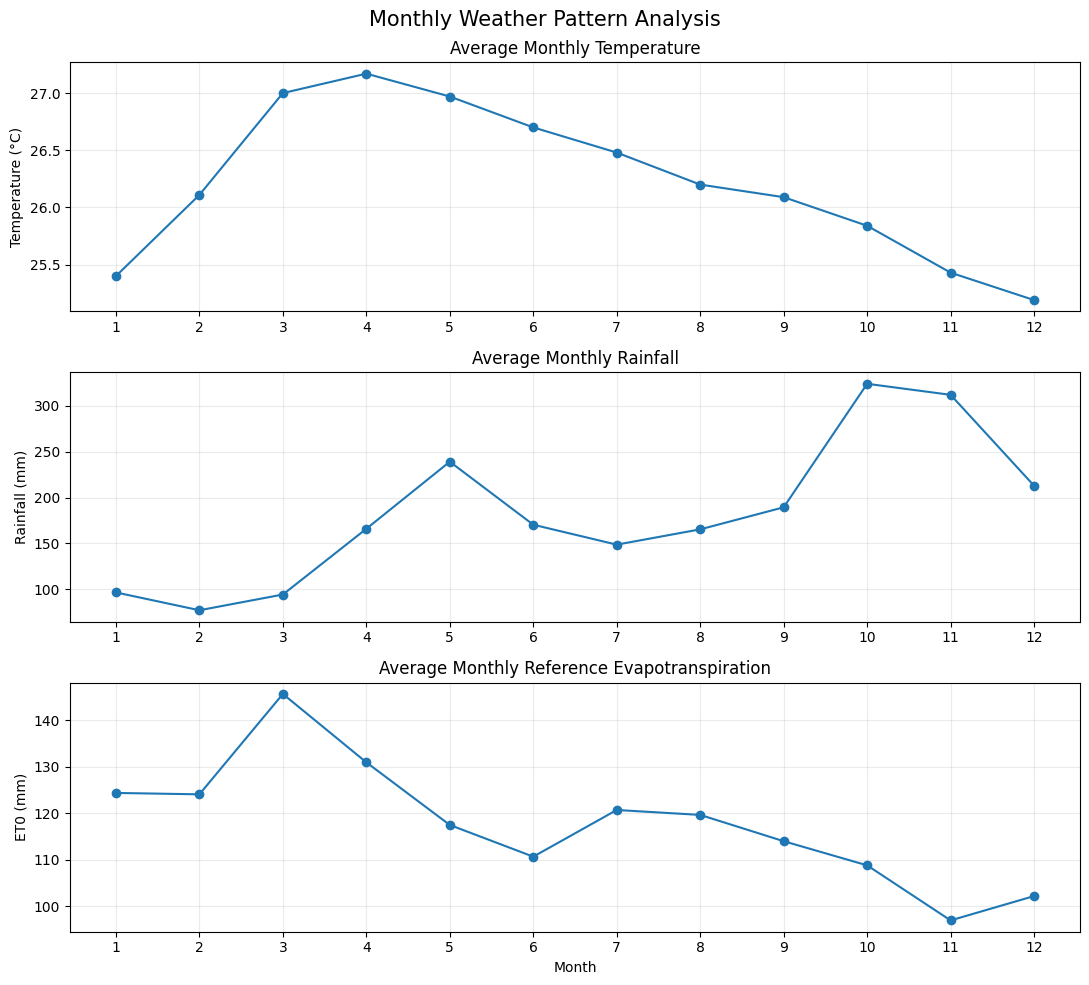

In [ ]:

print("\n\n" + "=" * 70)
print("EDA 6 - MONTHLY WEATHER PATTERN ANALYSIS")
print("=" * 70)


weather_features = [

    "monthly_temperature_c",
    "monthly_rainfall_mm",
    "monthly_et0_mm"

]


available_weather_features = [

    feature
    for feature in weather_features
    if feature in df.columns

]


if "month" not in df.columns:

    print(
        "\n'month' column was not found."
    )

elif len(available_weather_features) == 0:

    print(
        "\nNo monthly weather variables found."
    )

else:


    monthly_weather = (

        df
        .groupby("month")
        [available_weather_features]
        .mean()
        .sort_index()
        .round(2)

    )


    print(
        "\nAverage monthly weather conditions:"
    )

    print(monthly_weather)


    monthly_weather.to_csv(

        os.path.join(
            OUTPUT_DIR,
            "06_monthly_weather_summary.csv"
        )

    )


    fig, axes = plt.subplots(

        len(available_weather_features),
        1,

        figsize=(11, 10)

    )


    if len(available_weather_features) == 1:

        axes = [axes]


    titles = {

        "monthly_temperature_c":
            "Average Monthly Temperature",

        "monthly_rainfall_mm":
            "Average Monthly Rainfall",

        "monthly_et0_mm":
            "Average Monthly Reference Evapotranspiration"

    }


    y_labels = {

        "monthly_temperature_c":
            "Temperature (°C)",

        "monthly_rainfall_mm":
            "Rainfall (mm)",

        "monthly_et0_mm":
            "ET0 (mm)"

    }


    for ax, feature in zip(

        axes,
        available_weather_features

    ):

        ax.plot(

            monthly_weather.index,

            monthly_weather[feature],

            marker="o"

        )


        ax.set_title(

            titles.get(

                feature,

                feature
                .replace("_", " ")
                .title()

            )

        )


        ax.set_ylabel(

            y_labels.get(

                feature,

                feature

            )

        )


        ax.set_xticks(
            range(1, 13)
        )


        ax.grid(
            True,
            alpha=0.25
        )


    axes[-1].set_xlabel(
        "Month"
    )


    fig.suptitle(

        "Monthly Weather Pattern Analysis",

        fontsize=15

    )


    plt.tight_layout()


    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "06_monthly_weather_patterns.png"
        ),

        dpi=300,
        bbox_inches="tight"

    )


    plt.show()




EDA 7 - WATER BALANCE ANALYSIS

Water balance statistics:
count    486000.00
mean         63.10
std         148.76
min        -211.82
25%         -49.69
50%          43.81
75%         148.24
max         781.70
Name: water_balance_mm, dtype: float64

Negative water balance records : 184600
Zero/positive records          : 301400
Minimum water balance           : -211.82 mm
Maximum water balance           : 781.70 mm
Average water balance           : 63.10 mm


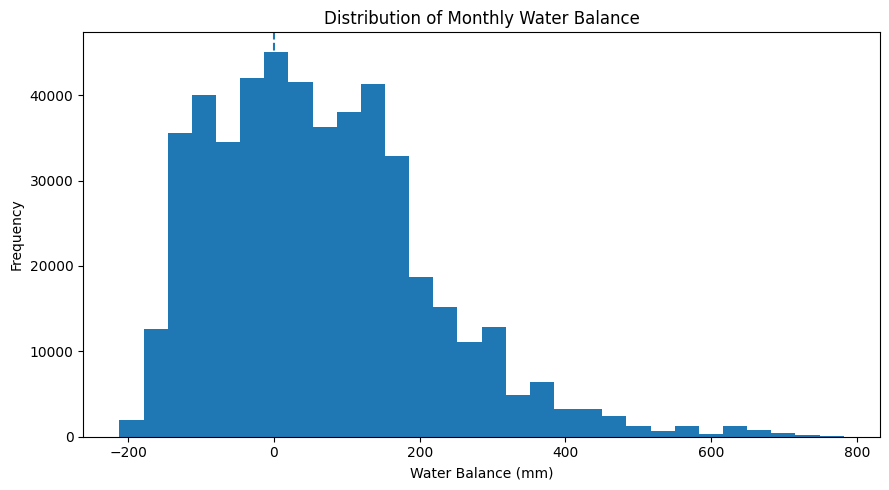

In [ ]:

print("\n\n" + "=" * 70)
print("EDA 7 - WATER BALANCE ANALYSIS")
print("=" * 70)


if "water_balance_mm" not in df.columns:

    print(
        "\nwater_balance_mm column was not found."
    )

else:

    water_balance = (

        df["water_balance_mm"]
        .dropna()

    )


    print("\nWater balance statistics:")

    print(
        water_balance
        .describe()
        .round(2)
    )


    negative_records = (
        water_balance < 0
    ).sum()


    non_negative_records = (
        water_balance >= 0
    ).sum()


    print(
        f"\nNegative water balance records : "
        f"{negative_records}"
    )


    print(
        f"Zero/positive records          : "
        f"{non_negative_records}"
    )


    print(
        f"Minimum water balance           : "
        f"{water_balance.min():.2f} mm"
    )


    print(
        f"Maximum water balance           : "
        f"{water_balance.max():.2f} mm"
    )


    print(
        f"Average water balance           : "
        f"{water_balance.mean():.2f} mm"
    )


   
    plt.figure(
        figsize=(9, 5)
    )


    plt.hist(

        water_balance,

        bins=30

    )


    plt.axvline(

        0,

        linestyle="--"

    )


    plt.title(

        "Distribution of Monthly Water Balance"

    )


    plt.xlabel(

        "Water Balance (mm)"

    )


    plt.ylabel(

        "Frequency"

    )


    plt.tight_layout()


    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "07_water_balance.png"
        ),

        dpi=300,
        bbox_inches="tight"

    )


    plt.show()



EDA 8 - CORRELATION ANALYSIS

Number of numerical variables: 21

Correlation matrix:
                          _soil_profile_id  latitude  longitude  elevation  \
_soil_profile_id                      1.00      0.00       0.00      -0.00   
latitude                              0.00      1.00       0.04      -0.00   
longitude                             0.00      0.04       1.00       0.32   
elevation                            -0.00     -0.00       0.32       1.00   
year                                 -0.00     -0.00       0.00       0.00   
month                                -0.00     -0.00      -0.00      -0.00   
N                                    -0.02     -0.00      -0.00       0.00   
P                                     0.06      0.00       0.00      -0.00   
K                                    -0.05     -0.00      -0.00       0.00   
ph                                    0.03      0.00       0.00      -0.00   
annual_temperature_c                  0.00      0.17   

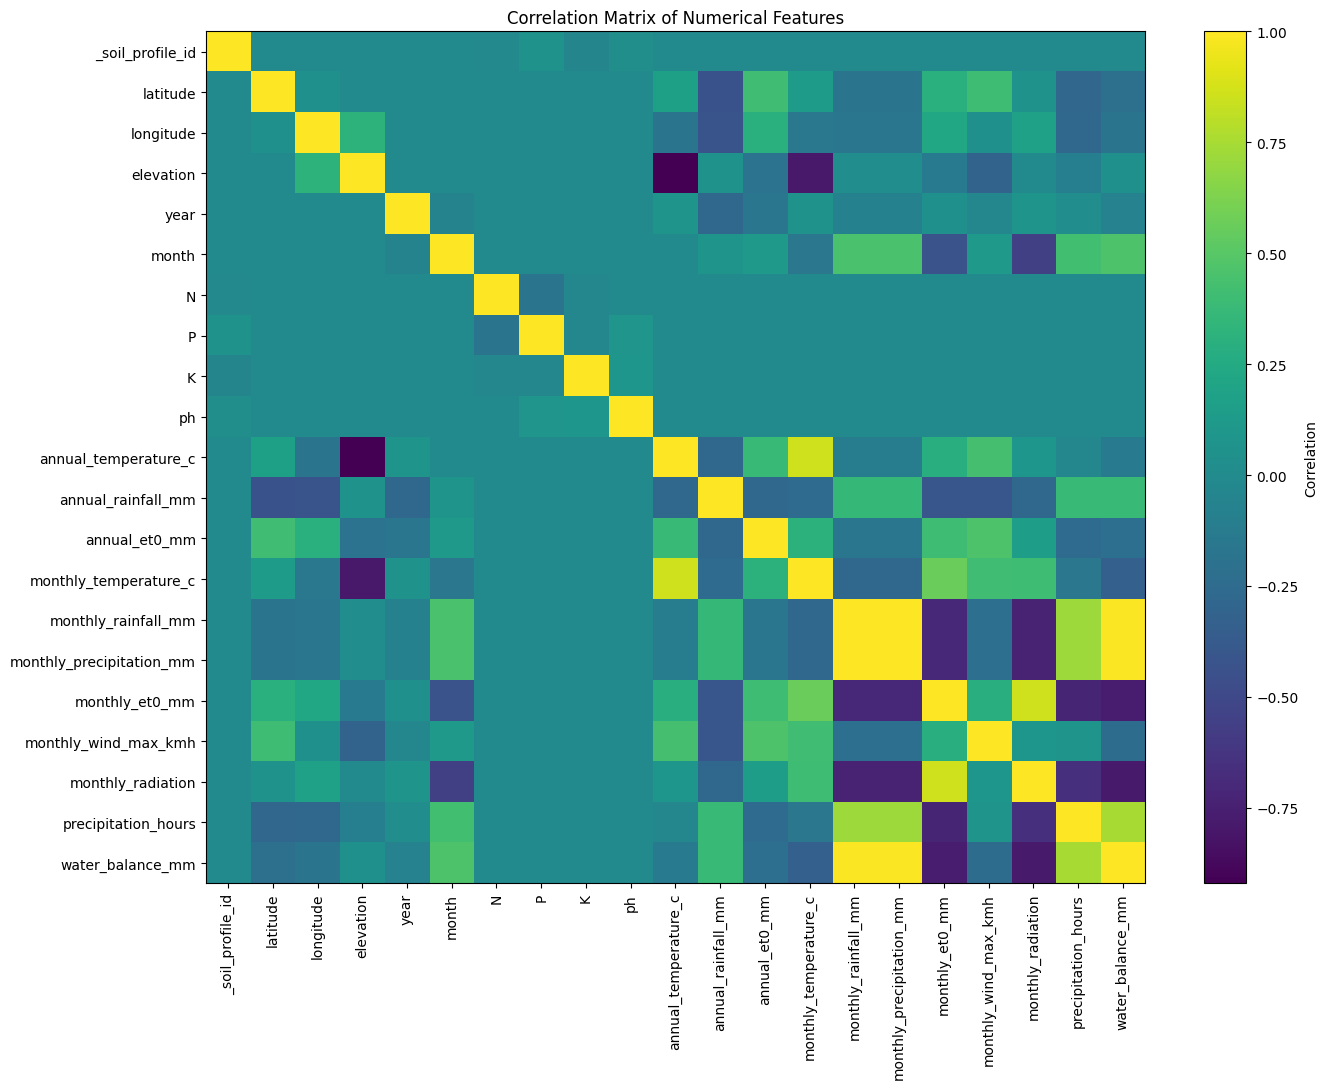

In [ ]:


print("\n\n" + "=" * 70)
print("EDA 8 - CORRELATION ANALYSIS")
print("=" * 70)


numeric_df = df.select_dtypes(
    include=np.number
)


print(
    "\nNumber of numerical variables:",
    numeric_df.shape[1]
)


if numeric_df.shape[1] < 2:

    print(
        "\nNot enough numerical variables "
        "for correlation analysis."
    )

else:

    correlation = (

        numeric_df
        .corr()
        .round(2)

    )


    print("\nCorrelation matrix:")

    print(correlation)


    correlation.to_csv(

        os.path.join(
            OUTPUT_DIR,
            "08_correlation_matrix.csv"
        )

    )


    plt.figure(
        figsize=(14, 11)
    )


    plt.imshow(

        correlation,

        aspect="auto"

    )


    plt.colorbar(
        label="Correlation"
    )


    plt.xticks(

        range(
            len(correlation.columns)
        ),

        correlation.columns,

        rotation=90

    )


    plt.yticks(

        range(
            len(correlation.columns)
        ),

        correlation.columns

    )


    plt.title(

        "Correlation Matrix of Numerical Features"

    )


    plt.tight_layout()


    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "08_correlation_matrix.png"
        ),

        dpi=300,
        bbox_inches="tight"

    )


    plt.show()


In [ ]:

print("\n\n" + "=" * 70)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 70)


print(
    f"""
Dataset:
    Rows    : {df.shape[0]}
    Columns : {df.shape[1]}

EDA performed:

    1. Dataset Overview
    2. Data Quality Analysis
    3. Descriptive Statistics
    4. Target Variable Distribution
    5. Soil Parameter Distribution
    6. Monthly Weather Pattern Analysis
    7. Water Balance Analysis
    8. Correlation Analysis

Results saved to:

    {os.path.abspath(OUTPUT_DIR)}
"""
)


print("=" * 70)
print("EDA analysis finished.")
print("=" * 70)



EDA COMPLETED SUCCESSFULLY

Dataset:
    Rows    : 486000
    Columns : 30

EDA performed:

    1. Dataset Overview
    2. Data Quality Analysis
    3. Descriptive Statistics
    4. Target Variable Distribution
    5. Soil Parameter Distribution
    6. Monthly Weather Pattern Analysis
    7. Water Balance Analysis
    8. Correlation Analysis

Results saved to:

    c:\Users\udnrm\AppData\Local\Programs\Microsoft VS Code\eda_outputs

EDA analysis finished.
